<a href="https://colab.research.google.com/github/Nithya080/Project/blob/main/Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('Train.csv')

In [3]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df.shape

(8523, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
df['Item_Weight'].describe()

,Item_Weight
count,7060.000000
mean,12.857645
std,4.643456
min,4.555000
25%,8.773750
50%,12.600000
75%,16.850000
max,21.350000


In [7]:
df['Item_Weight'].skew()

np.float64(0.0824262091221237)

In [8]:
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

In [9]:
df['Item_Weight'].isnull().sum()

np.int64(0)

In [10]:
df['Outlet_Size'] = df.groupby('Outlet_Type')['Outlet_Size'] \
                       .transform(lambda x: x.fillna(x.mode()[0]))

In [11]:
df['Outlet_Size'].isnull().sum()

np.int64(0)

In [12]:
size_mapping = {'Small': 0, 'Medium': 1, 'High': 2}
df['Outlet_Size'] = df['Outlet_Size'].map(size_mapping)

In [13]:
df = pd.get_dummies(df, columns=['Outlet_Type'], drop_first=True)

In [14]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [15]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,int64
Outlet_Location_Type,object


In [16]:
df = pd.get_dummies(df, columns=[
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Location_Type'
], drop_first=True)

In [17]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [18]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Visibility,float64
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,int64
Item_Outlet_Sales,float64
Outlet_Type_Supermarket Type1,int64
Outlet_Type_Supermarket Type2,int64


In [19]:
df = df.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1)

In [20]:
df.dtypes

,0
Item_Weight,float64
Item_Visibility,float64
Item_MRP,float64
Outlet_Establishment_Year,int64
Outlet_Size,int64
Item_Outlet_Sales,float64
Outlet_Type_Supermarket Type1,int64
Outlet_Type_Supermarket Type2,int64
Outlet_Type_Supermarket Type3,int64
Item_Fat_Content_Low Fat,int64


In [21]:
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [24]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.5776715627632091
RMSE: 1071.3897753341762


In [25]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2 Score: 0.5548317747239074
RMSE: 1099.9790502138253


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2 Score: 0.5960263685856616
RMSE: 1047.8493393072445


Text(0.5, 1.0, 'Sales Distribution')

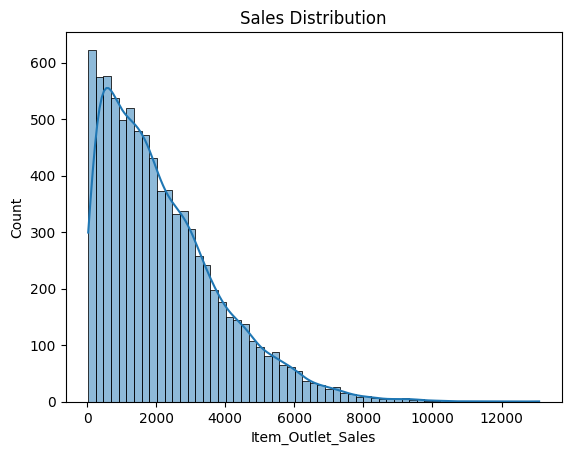

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['Item_Outlet_Sales'], kde=True)
plt.title("Sales Distribution")

([0, 1, 2], [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2')])

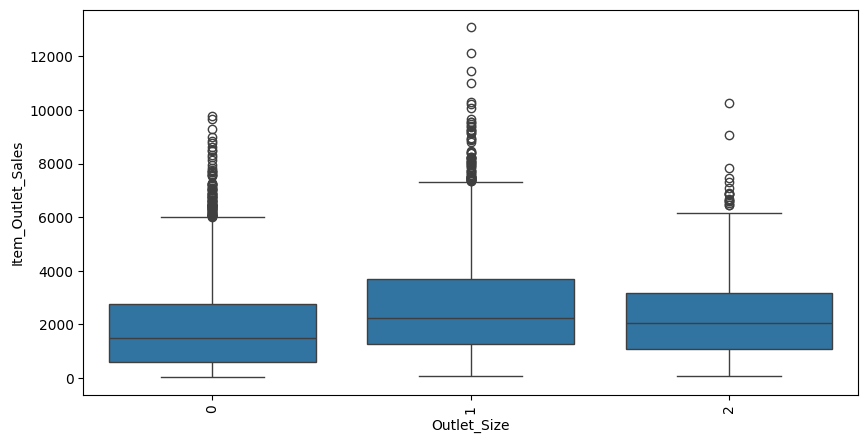

In [31]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Outlet_Size', y='Item_Outlet_Sales', data=df) # Changed 'Item_Type' to 'Outlet_Size'
plt.xticks(rotation=90)

<Axes: xlabel='Outlet_Location_Type_Tier 2', ylabel='Item_Outlet_Sales'>

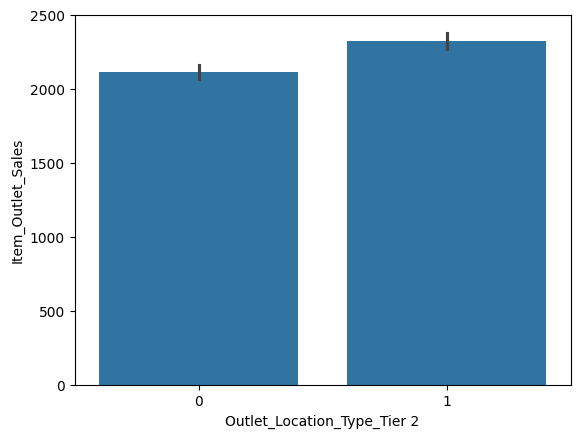

In [35]:
sns.barplot(x='Outlet_Location_Type_Tier 2', y='Item_Outlet_Sales', data=df)